<a href="https://colab.research.google.com/github/fabriciotonetta/flappy-bird-ia-neat/blob/main/notebooks/flappy_bird_ia_neat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# ETAPA 3 - CONFIGURAÇÃO DO AMBIENTE
# ============================================================
# Este bloco instala tudo que precisamos para rodar um jogo
# (Pygame) dentro de um ambiente em nuvem sem tela (Google Colab),
# além da biblioteca de Inteligência Artificial (NEAT).

# Instala o pacote do sistema "xvfb" (tela virtual) e o "x11-utils"
# (ferramentas auxiliares para essa tela virtual funcionar).
# O "!" no início diz ao Colab: "isso não é Python, é um comando de terminal".
!apt-get install -y xvfb x11-utils > /dev/null 2>&1

# Instala a biblioteca Python que controla essa tela virtual
# a partir do próprio Python (sem precisar usar o terminal toda hora).
!pip install pyvirtualdisplay > /dev/null 2>&1

# Instala o Pygame: biblioteca que usamos para desenhar o jogo
# (o pássaro, os canos, o fundo, etc).
!pip install pygame > /dev/null 2>&1

# Instala o NEAT-Python: biblioteca que implementa o algoritmo
# genético que vai evoluir as redes neurais (a "IA" do projeto).
!pip install neat-python > /dev/null 2>&1

print("✅ Ambiente configurado com sucesso!")

✅ Ambiente configurado com sucesso!


In [ ]:
# ============================================================
# ATIVANDO A TELA VIRTUAL (necessário 1x por sessão do Colab)
# ============================================================
from pyvirtualdisplay import Display  # importa a classe que cria a tela virtual

# Cria uma tela virtual com resolução 600x800 pixels (tamanho do nosso jogo)
# "visible=0" significa que ela é invisível para nós, mas existe para o Pygame.
virtual_display = Display(visible=0, size=(600, 800))

# Liga a tela virtual — a partir daqui, o Pygame "acredita" que tem uma tela.
virtual_display.start()

print("✅ Tela virtual ativada!")

✅ Tela virtual ativada!


In [ ]:
# ============================================================
# ETAPA 4 - PARTE 1: CONSTANTES E O PÁSSARO (BIRD)
# ============================================================
import pygame  # biblioteca usada para desenhar e controlar o jogo
import random  # vamos usar para gerar posições aleatórias dos canos (na Parte 2)

# Inicializa o motor interno do Pygame (necessário antes de usar qualquer função dele)
pygame.init()

# ------------------------------------------------------------
# CONSTANTES GERAIS DO JOGO
# ------------------------------------------------------------
LARGURA_TELA = 600          # largura da janela do jogo, em pixels
ALTURA_TELA = 800           # altura da janela do jogo, em pixels
FPS = 30                    # "Frames Per Second" - quantas vezes por segundo o jogo atualiza a tela

# Paleta de cores no formato RGB (Vermelho, Verde, Azul), de 0 a 255
COR_CEU = (135, 206, 250)        # azul claro, fundo do céu
COR_PASSARO = (255, 215, 0)      # amarelo dourado, corpo do pássaro
COR_BICO = (255, 140, 0)         # laranja, bico do pássaro
COR_OLHO = (0, 0, 0)             # preto, olho do pássaro
COR_BRANCO = (255, 255, 255)     # branco, usado em detalhes

# ------------------------------------------------------------
# CLASSE BIRD (PÁSSARO)
# ------------------------------------------------------------
# Uma "classe" é como uma fôrma de bolo: define como cada pássaro
# vai se comportar e quais informações ele guarda sobre si mesmo.
class Bird:
    # Constantes específicas do pássaro (física do pulo e da queda)
    VELOCIDADE_MAXIMA_QUEDA = 16    # velocidade máxima que ele pode cair (evita acelerar infinito)
    FORCA_PULO = -10.5              # impulso vertical do pulo (negativo = sobe na tela)
    GRAVIDADE = 3                   # quão rápido a velocidade de queda aumenta a cada instante

    def __init__(self, x, y):
        # "__init__" roda automaticamente quando criamos um novo pássaro.
        # Aqui guardamos os dados iniciais dele.
        self.x = x                  # posição horizontal inicial
        self.y = y                  # posição vertical inicial
        self.velocidade = 0         # velocidade vertical atual (começa parado)
        self.contador_tempo = 0     # conta quantos "instantes" passaram desde o último pulo
        self.altura_inicial = y     # guarda a altura no momento do pulo (usado no cálculo de física)
        self.raio = 18              # tamanho do corpo do pássaro (raio do círculo)
        self.angulo = 0             # ângulo de inclinação visual (sobe quando pula, desce quando cai)

    def pular(self):
        # Chamado quando o pássaro decide pular (seja você apertando uma tecla,
        # seja a IA decidindo isso futuramente).
        self.velocidade = self.FORCA_PULO   # aplica o impulso para cima
        self.contador_tempo = 0             # reinicia o contador de tempo (física do pulo)
        self.altura_inicial = self.y        # marca a altura onde o pulo começou

    def mover(self):
        # Chamado a cada frame do jogo para atualizar a posição do pássaro.
        self.contador_tempo += 1

        # Fórmula física simplificada de queda/pulo (movimento uniformemente acelerado).
        # Quanto mais tempo passa, mais a gravidade "puxa" o pássaro para baixo.
        deslocamento = self.velocidade * self.contador_tempo + 0.5 * self.GRAVIDADE * self.contador_tempo**2

        # Limita a velocidade de queda máxima, para o pássaro não acelerar infinitamente
        if deslocamento >= self.VELOCIDADE_MAXIMA_QUEDA:
            deslocamento = self.VELOCIDADE_MAXIMA_QUEDA

        self.y = self.y + deslocamento  # atualiza a posição vertical

        # Ajusta o ângulo visual: inclina para cima ao subir, para baixo ao cair
        if deslocamento < 0:
            self.angulo = 25
        else:
            self.angulo = max(self.angulo - 5, -80)

    def desenhar(self, tela):
        # Desenha o pássaro na tela usando formas geométricas simples.
        x, y = int(self.x), int(self.y)

        # Corpo (círculo amarelo)
        pygame.draw.circle(tela, COR_PASSARO, (x, y), self.raio)

        # Bico (triângulo laranja, na frente do corpo)
        pygame.draw.polygon(
            tela, COR_BICO,
            [(x + self.raio, y), (x + self.raio + 12, y - 4), (x + self.raio + 12, y + 4)]
        )

        # Olho (círculo branco com um pontinho preto no centro)
        pygame.draw.circle(tela, COR_BRANCO, (x + 6, y - 6), 6)
        pygame.draw.circle(tela, COR_OLHO, (x + 8, y - 6), 3)

print("✅ Classe Bird criada com sucesso!")

✅ Classe Bird criada com sucesso!


In [ ]:
# ============================================================
# ETAPA 4 - PARTE 2: CANOS (PIPE) E CHÃO (BASE)
# ============================================================

# Cores adicionais para os canos e o chão
COR_CANO = (34, 139, 34)        # verde escuro, corpo do cano
COR_CANO_BORDA = (20, 90, 20)   # verde mais escuro, borda do cano (dá efeito 3D)
COR_CHAO = (222, 184, 135)      # marrom claro (cor de areia), o chão
COR_GRAMA = (50, 160, 50)       # verde, faixa de grama por cima do chão

# ------------------------------------------------------------
# CLASSE PIPE (CANO)
# ------------------------------------------------------------
class Pipe:
    DISTANCIA_GAP = 200      # tamanho do espaço vertical livre entre o cano de cima e o de baixo
    VELOCIDADE = 5           # velocidade com que o cano se move para a esquerda
    LARGURA = 70             # largura do cano, em pixels

    def __init__(self, x):
        self.x = x  # posição horizontal inicial do cano (vem da direita para a esquerda)

        # Define aleatoriamente onde fica o "topo" do gap (espaço livre).
        # Isso garante que cada cano tenha uma altura de passagem diferente.
        self.altura_topo = random.randrange(50, 450)

        # A partir da altura do topo, calculamos onde termina o cano de baixo
        # (sempre DISTANCIA_GAP pixels abaixo do topo do gap).
        self.altura_base = self.altura_topo + self.DISTANCIA_GAP

        self.passou = False  # controla se o pássaro já passou por esse cano (para pontuação)

    def mover(self):
        # A cada frame, o cano anda para a esquerda (efeito de "o pássaro avançando")
        self.x -= self.VELOCIDADE

    def desenhar(self, tela):
        x = int(self.x)

        # Cano de CIMA: vai do topo da tela (y=0) até a altura_topo
        pygame.draw.rect(tela, COR_CANO, (x, 0, self.LARGURA, self.altura_topo))
        pygame.draw.rect(tela, COR_CANO_BORDA, (x, 0, self.LARGURA, self.altura_topo), 4)
        # "boquinha" do cano de cima (parte um pouco mais larga, efeito visual clássico)
        pygame.draw.rect(tela, COR_CANO, (x - 5, self.altura_topo - 30, self.LARGURA + 10, 30))
        pygame.draw.rect(tela, COR_CANO_BORDA, (x - 5, self.altura_topo - 30, self.LARGURA + 10, 30), 4)

        # Cano de BAIXO: vai da altura_base até o fim da tela
        altura_cano_baixo = ALTURA_TELA - self.altura_base
        pygame.draw.rect(tela, COR_CANO, (x, self.altura_base, self.LARGURA, altura_cano_baixo))
        pygame.draw.rect(tela, COR_CANO_BORDA, (x, self.altura_base, self.LARGURA, altura_cano_baixo), 4)
        # "boquinha" do cano de baixo
        pygame.draw.rect(tela, COR_CANO, (x - 5, self.altura_base, self.LARGURA + 10, 30))
        pygame.draw.rect(tela, COR_CANO_BORDA, (x - 5, self.altura_base, self.LARGURA + 10, 30), 4)

    def colidiu(self, bird):
        # Verifica se o pássaro tocou em algum dos dois canos.
        # Usamos retângulos de colisão (bounding boxes) para simplificar o cálculo.
        bird_rect = pygame.Rect(bird.x - bird.raio, bird.y - bird.raio, bird.raio * 2, bird.raio * 2)
        cano_topo_rect = pygame.Rect(self.x, 0, self.LARGURA, self.altura_topo)
        cano_base_rect = pygame.Rect(self.x, self.altura_base, self.LARGURA, ALTURA_TELA - self.altura_base)

        # "colliderect" é uma função pronta do Pygame que retorna True se dois
        # retângulos estão se sobrepondo (ou seja, se houve colisão).
        return bird_rect.colliderect(cano_topo_rect) or bird_rect.colliderect(cano_base_rect)


# ------------------------------------------------------------
# CLASSE BASE (CHÃO)
# ------------------------------------------------------------
class Base:
    VELOCIDADE = 5             # mesma velocidade dos canos, para manter a ilusão de jogo coeso
    ALTURA_CHAO = 100          # altura (em pixels) da faixa de chão, contada de baixo para cima

    def __init__(self):
        # Usamos duas faixas de chão lado a lado para criar um "loop infinito":
        # quando uma sai da tela pela esquerda, ela "pula" para depois da outra.
        self.y = ALTURA_TELA - self.ALTURA_CHAO
        self.x1 = 0
        self.x2 = LARGURA_TELA

    def mover(self):
        self.x1 -= self.VELOCIDADE
        self.x2 -= self.VELOCIDADE

        # Quando a primeira faixa sai totalmente da tela, ela volta para o final da segunda
        if self.x1 + LARGURA_TELA < 0:
            self.x1 = self.x2 + LARGURA_TELA
        if self.x2 + LARGURA_TELA < 0:
            self.x2 = self.x1 + LARGURA_TELA

    def desenhar(self, tela):
        # Desenha as duas faixas de chão (areia + grama por cima)
        pygame.draw.rect(tela, COR_CHAO, (self.x1, self.y, LARGURA_TELA, self.ALTURA_CHAO))
        pygame.draw.rect(tela, COR_CHAO, (self.x2, self.y, LARGURA_TELA, self.ALTURA_CHAO))
        pygame.draw.rect(tela, COR_GRAMA, (self.x1, self.y, LARGURA_TELA, 12))
        pygame.draw.rect(tela, COR_GRAMA, (self.x2, self.y, LARGURA_TELA, 12))

print("✅ Classes Pipe e Base criadas com sucesso!")

✅ Classes Pipe e Base criadas com sucesso!


In [ ]:
# ============================================================
# ETAPA 4 - PARTE 3: LOOP DO JOGO + GRAVAÇÃO EM VÍDEO
# ============================================================
import cv2      # biblioteca para criar o arquivo de vídeo a partir das fotos dos frames
import numpy as np  # usada para converter os frames do Pygame em um formato de imagem
from IPython.display import Video, display  # para exibir o vídeo dentro do próprio notebook
import pygame  # Importar Pygame para garantir que esteja no escopo
pygame.init() # Inicializar Pygame aqui também, para robustez

def desenhar_tela(tela, passaros, canos, base, pontuacao):
    """
    Função responsável por desenhar TODOS os elementos do jogo em um único frame:
    fundo, canos, chão, pássaros e o placar de pontos.
    """
    tela.fill(COR_CEU)  # pinta o fundo (céu) antes de desenhar o resto, todo frame

    for cano in canos:
        cano.desenhar(tela)

    base.desenhar(tela)

    for passaro in passaros:
        passaro.desenhar(tela)

    # Desenha o placar de pontos no topo da tela
    fonte = pygame.font.SysFont("arial", 40, bold=True)
    texto_pontos = fonte.render(str(pontuacao), True, COR_BRANCO)
    tela.blit(texto_pontos, (LARGURA_TELA / 2 - texto_pontos.get_width() / 2, 30))

    pygame.display.update()  # confirma o desenho do frame atual


def capturar_frame(tela):
    """
    'Fotografa' o estado atual da tela do jogo e devolve essa foto em um
    formato que o OpenCV (cv2) entende, para depois transformamos em vídeo.
    """
    frame = pygame.surfarray.array3d(tela)   # converte a tela em uma matriz de pixels (array)
    frame = np.transpose(frame, (1, 0, 2))   # ajusta a orientação (Pygame e OpenCV organizam eixos diferente)
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)  # OpenCV usa ordem de cores BGR, não RGB
    return frame


def rodar_teste_visual(duracao_segundos=15):
    """
    Roda uma partida de TESTE (decisão de pulo simples, não é a IA ainda)
    apenas para confirmar que toda a parte visual do jogo está funcionando.
    Grava um vídeo do resultado para exibirmos no notebook.
    """
    tela = pygame.display.set_mode((LARGURA_TELA, ALTURA_TELA))  # cria a "superfície" de desenho do jogo
    relogio = pygame.time.Clock()  # ajuda a manter o jogo correndo a uma velocidade constante (FPS)

    passaros = [Bird(230, 350)]   # cria um único pássaro de teste, posição inicial
    base = Base()
    canos = [Pipe(700)]           # primeiro cano, começando fora da tela à direita
    pontuacao = 0

    frames = []  # lista onde vamos guardar cada "foto" do jogo, frame a frame

    total_frames = duracao_segundos * FPS  # quantos frames precisamos gravar no total

    for _ in range(total_frames):
        relogio.tick(FPS)  # controla a velocidade do loop

        for passaro in passaros:
            passaro.mover()
            # Decisão de pulo SIMPLES e TEMPORÁRIA (não é IA ainda!):
            # pula sempre que estiver caindo rápido demais, só para o teste visual.
            if passaro.y > 600:
                passaro.pular()

        # Move os canos e remove os que já saíram totalmente da tela
        canos_restantes = []
        adicionar_novo_cano = False

        for cano in canos:
            cano.mover()

            if not cano.passou and cano.x < passaros[0].x:
                cano.passou = True
                pontuacao += 1
                adicionar_novo_cano = True

            if cano.x + cano.LARGURA > 0:
                canos_restantes.append(cano)

        canos = canos_restantes
        if adicionar_novo_cano:
            canos.append(Pipe(LARGURA_TELA + 50))

        base.mover()

        desenhar_tela(tela, passaros, canos, base, pontuacao)
        frames.append(capturar_frame(tela))

    return frames


def salvar_video(frames, caminho_arquivo="teste_visual.mp4"):
    """
    Junta a lista de frames (fotos) em um único arquivo de vídeo .mp4.
    """
    altura, largura, _ = frames[0].shape
    video = cv2.VideoWriter(caminho_arquivo, cv2.VideoWriter_fourcc(*"mp4v"), FPS, (largura, altura))

    for frame in frames:
        video.write(frame)

    video.release()  # finaliza e salva o arquivo de vídeo no disco
    print(f"✅ Vídeo salvo em: {caminho_arquivo}")


# Executa o teste visual e salva o vídeo
frames_teste = rodar_teste_visual(duracao_segundos=15)
salvar_video(frames_teste, "teste_visual.mp4")

# Exibe o vídeo diretamente dentro do notebook
display(Video("teste_visual.mp4", embed=True, width=400))

✅ Vídeo salvo em: teste_visual.mp4


🔍 TESTE 1: Verificando os frames capturados
Quantidade de frames capturados: 450
Formato (shape) do primeiro frame: (800, 600, 3)
Valor mínimo de pixel: 0 | Valor máximo de pixel: 255

🔍 TESTE 2: Verificando o arquivo de vídeo salvo
Arquivo encontrado: teste_visual.mp4
Tamanho do arquivo: 1062.48 KB

🔍 TESTE 3: Exibindo o primeiro frame como imagem estática


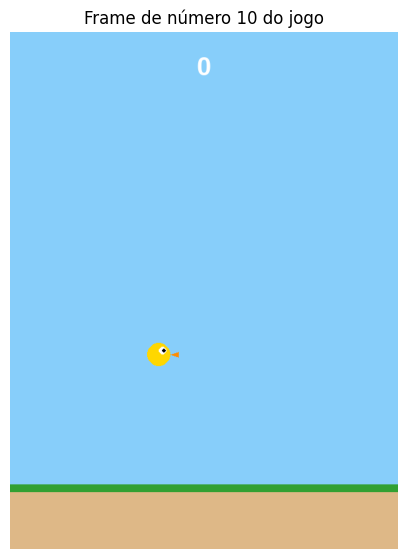

In [ ]:
# ============================================================
# DIAGNÓSTICO - VERIFICANDO O PROBLEMA DO VÍDEO
# ============================================================
import os  # vamos usar para checar informações do arquivo gerado (tamanho, existência)

# --- TESTE 1: os frames foram capturados corretamente? ---
print("🔍 TESTE 1: Verificando os frames capturados")
print(f"Quantidade de frames capturados: {len(frames_teste)}")

if len(frames_teste) > 0:
    primeiro_frame = frames_teste[0]
    print(f"Formato (shape) do primeiro frame: {primeiro_frame.shape}")
    print(f"Valor mínimo de pixel: {primeiro_frame.min()} | Valor máximo de pixel: {primeiro_frame.max()}")
    # Se min e max forem iguais (ex: tudo 0), significa que o frame está
    # completamente preto - ou seja, o Pygame não desenhou nada de fato.
else:
    print("⚠️ A lista de frames está VAZIA - o problema é na captura, não no vídeo.")

print()

# --- TESTE 2: o arquivo de vídeo foi gerado com conteúdo? ---
print("🔍 TESTE 2: Verificando o arquivo de vídeo salvo")
if os.path.exists("teste_visual.mp4"):
    tamanho_kb = os.path.getsize("teste_visual.mp4") / 1024
    print(f"Arquivo encontrado: teste_visual.mp4")
    print(f"Tamanho do arquivo: {tamanho_kb:.2f} KB")
    if tamanho_kb < 5:
        print("⚠️ Arquivo muito pequeno - provavelmente está vazio/corrompido.")
else:
    print("⚠️ Arquivo teste_visual.mp4 NÃO foi encontrado - falhou ao salvar.")

print()

# --- TESTE 3: visualizando um frame como IMAGEM (não vídeo) ---
print("🔍 TESTE 3: Exibindo o primeiro frame como imagem estática")
import matplotlib.pyplot as plt  # biblioteca simples para mostrar imagens no notebook

if len(frames_teste) > 0:
    # Convertendo de volta BGR -> RGB, pois o OpenCV usa BGR e o matplotlib espera RGB
    frame_rgb = cv2.cvtColor(frames_teste[10], cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 7))
    plt.imshow(frame_rgb)
    plt.axis("off")  # remove os eixos numéricos, deixando só a imagem
    plt.title("Frame de número 10 do jogo")
    plt.show()

In [ ]:
# ============================================================
# CORREÇÃO - CONVERTENDO O VÍDEO PARA UM CODEC COMPATÍVEL COM NAVEGADORES
# ============================================================
# O OpenCV salva o vídeo com o codec "mp4v", que gera um arquivo .mp4
# válido, mas que players de navegador (como o do Google Colab) muitas
# vezes não conseguem reproduzir. O ffmpeg é uma ferramenta padrão da
# indústria para conversão de vídeo, e vamos usá-la para "re-codificar"
# o vídeo no formato H.264, que é o mais aceito universalmente.

# "-y" sobrescreve o arquivo de saída se ele já existir
# "-i teste_visual.mp4" define o vídeo de entrada (o que já geramos)
# "-vcodec libx264" define o codec de saída como H.264
# "-pix_fmt yuv420p" garante compatibilidade máxima com navegadores
!ffmpeg -y -i teste_visual.mp4 -vcodec libx264 -pix_fmt yuv420p teste_visual_corrigido.mp4 > /dev/null 2>&1

print("✅ Vídeo convertido com sucesso!")

# Exibe a versão corrigida do vídeo
display(Video("teste_visual_corrigido.mp4", embed=True, width=400))

✅ Vídeo convertido com sucesso!


In [ ]:
# ============================================================
# ETAPA 5 - PARTE 1: ARQUIVO DE CONFIGURAÇÃO DO NEAT (ATUALIZADO)
# ============================================================
config_neat = """
[NEAT]
fitness_criterion      = max
fitness_threshold      = 1000
pop_size               = 50
reset_on_extinction    = False
no_fitness_termination = False

[DefaultGenome]
# --- estrutura da rede neural ---
num_inputs              = 3
num_hidden              = 0
num_outputs             = 1
feed_forward            = True
initial_connection      = full

# --- pesos das conexões (os "fios" entre neurônios) ---
weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_max_value        = 30
weight_min_value        = -30
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.1

# --- bias (um ajuste extra que cada neurônio pode aprender) ---
bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_max_value          = 30
bias_min_value          = -30
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

# --- response (multiplicador extra de sensibilidade de cada neurônio) ---
response_init_mean      = 1.0
response_init_stdev      = 0.0
response_max_value       = 30
response_min_value       = -30
response_mutate_power    = 0.0
response_mutate_rate     = 0.0
response_replace_rate    = 0.0

# --- função de ativação (transforma a soma dos sinais em uma decisão) ---
activation_default      = tanh
activation_mutate_rate  = 0.0
activation_options      = tanh

# --- função de agregação (como o neurônio soma os sinais recebidos) ---
aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

# --- taxas de criação/remoção de conexões e neurônios extras ---
conn_add_prob           = 0.5
conn_delete_prob        = 0.5
node_add_prob           = 0.2
node_delete_prob        = 0.2
enabled_default         = True
enabled_mutate_rate     = 0.01

# --- compatibilidade genética (usada para agrupar redes parecidas em "espécies") ---
compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 2

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2
"""

with open("config-feedforward.txt", "w") as arquivo:
    arquivo.write(config_neat)

print("✅ Arquivo de configuração do NEAT criado com sucesso!")

✅ Arquivo de configuração do NEAT criado com sucesso!


In [ ]:
# ============================================================
# ETAPA 5 - PARTE 2: SUPORTE A MÚLTIPLOS PÁSSAROS + COLISÃO ATIVA
# ============================================================

def encontrar_cano_proximo(passaro, canos):
    """
    Dado um pássaro e a lista de canos na tela, retorna o cano mais
    próximo que ainda está na frente dele (ou seja, ele ainda não passou).
    Esse é o cano que a rede neural vai "observar" para decidir se pula.
    """
    if len(canos) == 1:
        # Se só existe 1 cano na tela, não tem o que escolher: é ele mesmo.
        return canos[0]

    # Se o pássaro já passou pelo primeiro cano (ultrapassou sua borda direita),
    # então o cano relevante passa a ser o segundo da lista.
    if passaro.x > canos[0].x + canos[0].LARGURA:
        return canos[1]
    else:
        return canos[0]


def rodar_teste_multiplos_passaros(quantidade_passaros=10, duracao_segundos=15):
    """
    Roda um teste com VÁRIOS pássaros ao mesmo tempo (ainda com uma decisão
    de pulo simples e provisória — a IA de verdade entra na Parte 3),
    mas agora com a COLISÃO ATIVA: pássaros que baterem nos canos ou
    saírem da tela são removidos da lista durante o jogo.
    """
    tela = pygame.display.set_mode((LARGURA_TELA, ALTURA_TELA))
    relogio = pygame.time.Clock()

    # Cria vários pássaros, todos começando na mesma posição inicial.
    # Cada um vai se comportar de forma levemente diferente, porque damos
    # a cada um um "limite de altura" para pular um pouco diferente -
    # isso é só para simularmos visualmente a diversidade que a IA real
    # vai ter na Parte 3 (cada rede neural decide de um jeito diferente).
    passaros = [Bird(230, 350) for _ in range(quantidade_passaros)]
    limites_pulo = [550 + (i * 10) for i in range(quantidade_passaros)]  # variação proposital

    base = Base()
    canos = [Pipe(700)]
    pontuacao = 0
    frames = []
    total_frames = duracao_segundos * FPS

    for _ in range(total_frames):
        relogio.tick(FPS)

        # Se todos os pássaros já morreram, não tem sentido continuar gravando.
        if len(passaros) == 0:
            break

        cano_atual = encontrar_cano_proximo(passaros[0], canos) if passaros else None

        # Percorremos uma CÓPIA da lista de índices, de trás para frente,
        # para podermos remover pássaros da lista original sem causar bugs
        # de "saltar" elementos durante o loop.
        for i in range(len(passaros) - 1, -1, -1):
            passaro = passaros[i]
            passaro.mover()

            # Decisão de pulo provisória (cada pássaro com seu próprio limite,
            # só para teste visual - a IA real vem na Parte 3)
            if passaro.y > limites_pulo[i % len(limites_pulo)]:
                passaro.pular()

            # --- VERIFICAÇÃO DE MORTE ---
            morreu = False

            # Morreu se bateu em algum cano
            for cano in canos:
                if cano.colidiu(passaro):
                    morreu = True
                    break

            # Morreu se saiu da tela (por cima ou por baixo)
            if passaro.y + passaro.raio >= ALTURA_TELA - Base.ALTURA_CHAO or passaro.y < 0:
                morreu = True

            if morreu:
                passaros.pop(i)  # remove esse pássaro da lista - ele "morreu"

        # Move os canos e remove os que já saíram totalmente da tela
        canos_restantes = []
        adicionar_novo_cano = False

        for cano in canos:
            cano.mover()
            if passaros and not cano.passou and cano.x < passaros[0].x:
                cano.passou = True
                pontuacao += 1
                adicionar_novo_cano = True
            if cano.x + cano.LARGURA > 0:
                canos_restantes.append(cano)

        canos = canos_restantes
        if adicionar_novo_cano:
            canos.append(Pipe(LARGURA_TELA + 50))

        base.mover()

        desenhar_tela(tela, passaros, canos, base, pontuacao)
        frames.append(capturar_frame(tela))

    print(f"✅ Teste concluído. Pássaros sobreviventes no final: {len(passaros)} de {quantidade_passaros}")
    return frames


def salvar_video_corrigido(frames, nome_base="video"):
    """
    Versão atualizada da função de salvar vídeo: já faz a conversão
    para H.264 automaticamente (correção que fizemos via ffmpeg),
    sem precisarmos rodar esse passo manualmente de novo.
    """
    altura, largura, _ = frames[0].shape
    caminho_bruto = f"{nome_base}_bruto.mp4"
    caminho_final = f"{nome_base}.mp4"

    video = cv2.VideoWriter(caminho_bruto, cv2.VideoWriter_fourcc(*"mp4v"), FPS, (largura, altura))
    for frame in frames:
        video.write(frame)
    video.release()

    # Converte automaticamente para o codec compatível com navegadores
    os.system(f"ffmpeg -y -i {caminho_bruto} -vcodec libx264 -pix_fmt yuv420p {caminho_final} > /dev/null 2>&1")

    print(f"✅ Vídeo salvo e convertido: {caminho_final}")
    return caminho_final


# Executa o teste com múltiplos pássaros e colisão ativa
frames_multiplos = rodar_teste_multiplos_passaros(quantidade_passaros=10, duracao_segundos=15)
caminho_video = salvar_video_corrigido(frames_multiplos, "teste_multiplos_passaros")
display(Video(caminho_video, embed=True, width=400))

✅ Teste concluído. Pássaros sobreviventes no final: 0 de 10
✅ Vídeo salvo e convertido: teste_multiplos_passaros.mp4


In [ ]:
# ============================================================
# ETAPA 5 - PARTE 3: TREINAMENTO COM NEAT (GERAÇÕES REAIS)
# ============================================================
import neat  # biblioteca que implementa o algoritmo genético NEAT

GERACAO_ATUAL = 0  # variável global só para sabermos em qual geração estamos (usada nos prints)

def avaliar_genomas(genomas, config):
    """
    Esta é a função "de avaliação" que o NEAT-Python chama automaticamente
    para CADA geração. Recebe a lista de genomas (cérebros) dessa geração
    e a configuração do NEAT. Aqui é onde rodamos o jogo de verdade,
    com cada genoma controlando um pássaro.
    """
    global GERACAO_ATUAL
    GERACAO_ATUAL += 1

    tela = pygame.display.set_mode((LARGURA_TELA, ALTURA_TELA))
    relogio = pygame.time.Clock()

    passaros = []      # lista de pássaros (um por genoma)
    redes = []          # lista das redes neurais (uma por pássaro, na mesma ordem)
    genomas_ativos = [] # lista dos genomas correspondentes (para darmos fitness depois)

    for _, genoma in genomas:
        rede = neat.nn.FeedForwardNetwork.create(genoma, config)
        redes.append(rede)
        passaros.append(Bird(230, 350))
        genoma.fitness = 0
        genomas_ativos.append(genoma)

    base = Base()
    canos = [Pipe(700)]
    pontuacao = 0

    MAXIMO_FRAMES_POR_GERACAO = 1800  # equivale a 60 segundos, com FPS = 30

    for frame_atual in range(MAXIMO_FRAMES_POR_GERACAO):
        # OBS: removemos "relogio.tick(FPS)" também, pois ele serve para
        # limitar a velocidade do jogo para o OLHO HUMANO acompanhar (30 FPS).
        # Durante o treinamento (sem desenho na tela), queremos que o código
        # rode o MAIS RÁPIDO possível, sem essa limitação artificial.

        if len(passaros) == 0:
            break

        cano_atual = encontrar_cano_proximo(passaros[0], canos)

        for i in range(len(passaros) - 1, -1, -1):
            passaro = passaros[i]
            genomas_ativos[i].fitness += 0.1
            passaro.mover()

            entrada = (
                passaro.y,
                abs(passaro.y - cano_atual.altura_topo),
                abs(passaro.y - cano_atual.altura_base),
            )
            saida = redes[i].activate(entrada)

            if saida[0] > 0.5:
                passaro.pular()

            morreu = False
            for cano in canos:
                if cano.colidiu(passaro):
                    morreu = True
                    break
            if passaro.y + passaro.raio >= ALTURA_TELA - Base.ALTURA_CHAO or passaro.y < 0:
                morreu = True

            if morreu:
                genomas_ativos[i].fitness -= 1
                passaros.pop(i)
                redes.pop(i)
                genomas_ativos.pop(i)

        canos_restantes = []
        adicionar_novo_cano = False

        for cano in canos:
            cano.mover()
            if passaros and not cano.passou and cano.x < passaros[0].x:
                cano.passou = True
                pontuacao += 1
                adicionar_novo_cano = True
                for genoma in genomas_ativos:
                    genoma.fitness += 5
            if cano.x + cano.LARGURA > 0:
                canos_restantes.append(cano)

        canos = canos_restantes
        if adicionar_novo_cano:
            canos.append(Pipe(LARGURA_TELA + 50))

        base.mover()
        # Linha "desenhar_tela(...)" removida de propósito: não desenhamos
        # graficamente durante o treinamento, só calculamos - isso torna
        # o treinamento MUITO mais rápido (de horas para poucos minutos).

    print(f"🧬 Geração {GERACAO_ATUAL} finalizada | Pontuação máxima: {pontuacao} | Pássaros restantes: {len(passaros)}")


def rodar_treinamento(numero_geracoes=30):
    """
    Função principal que inicia o treinamento do NEAT: carrega a
    configuração, cria a população inicial e manda o NEAT evoluir
    por várias gerações, chamando "avaliar_genomas" em cada uma.
    """
    # Carrega o arquivo de configuração que criamos na Parte 1
    config = neat.config.Config(
        neat.DefaultGenome,
        neat.DefaultReproduction,
        neat.DefaultSpeciesSet,
        neat.DefaultStagnation,
        "config-feedforward.txt",
    )

    # Cria a população inicial (50 genomas aleatórios, conforme pop_size)
    populacao = neat.Population(config)

    # Adiciona um "repórter" que imprime estatísticas no console a cada geração
    populacao.add_reporter(neat.StdOutReporter(True))

    # Roda o treinamento: o NEAT chama "avaliar_genomas" repetidamente,
    # uma vez por geração, até o limite de gerações ou até bater o fitness_threshold.
    melhor_genoma = populacao.run(avaliar_genomas, numero_geracoes)

    return melhor_genoma, config


# Inicia o treinamento por 30 gerações (pode ajustar esse número depois)
melhor_genoma, config_usada = rodar_treinamento(numero_geracoes=30)

print("\n✅ Treinamento concluído!")


 ****** Running generation 0 ****** 

🧬 Geração 1 finalizada | Pontuação máxima: 2 | Pássaros restantes: 0
Population's average fitness: 3.74800 stdev: 4.66529
Best fitness: 29.60000 - size: (1, 3) - species 1 - id 13
Average adjusted fitness: 0.087
Mean genetic distance 1.033, standard deviation 0.391
Population of 50 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0    50     29.600    0.087     0
Total extinctions: 0
Generation time: 0.070 sec

 ****** Running generation 1 ****** 

🧬 Geração 2 finalizada | Pontuação máxima: 21 | Pássaros restantes: 1
Population's average fitness: 12.83600 stdev: 40.45802
Best fitness: 285.00000 - size: (1, 2) - species 1 - id 84
Average adjusted fitness: 0.041
Mean genetic distance 1.256, standard deviation 0.424
Population of 50 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ===

In [ ]:
# ============================================================
# ETAPA 5 - PARTE 4: VISUALIZAÇÃO DA REDE NEURAL EM TEMPO REAL
# ============================================================

# Cores usadas no painel da rede neural
COR_PAINEL_FUNDO = (20, 20, 30)        # cinza bem escuro, fundo do painel
COR_NEURONIO_INATIVO = (80, 80, 90)    # cinza, neurônio "apagado"
COR_NEURONIO_ATIVO = (255, 230, 0)     # amarelo vibrante, neurônio "aceso"
COR_CONEXAO_POSITIVA = (60, 200, 100)  # verde, peso que incentiva pular
COR_CONEXAO_NEGATIVA = (220, 60, 60)   # vermelho, peso que desincentiva pular
COR_TEXTO_PAINEL = (255, 255, 255)     # branco, textos do painel


def gerar_posicoes_neuronios(net, x_painel, y_painel, largura_painel, altura_painel):
    """
    Calcula em que posição (x, y) cada neurônio da rede deve ser desenhado
    dentro do painel, organizando-os em 3 colunas: entradas, ocultos, saída.
    """
    posicoes = {}

    # --- COLUNA DAS ENTRADAS (esquerda) ---
    entradas = net.input_nodes
    espaco_entre_entradas = altura_painel / (len(entradas) + 1)
    for indice, chave_no in enumerate(entradas):
        x = x_painel + 30
        y = y_painel + espaco_entre_entradas * (indice + 1)
        posicoes[chave_no] = (x, y)

    # --- COLUNA DOS OCULTOS (meio) ---
    # Identificamos os neurônios ocultos como todos os que NÃO são
    # entrada nem saída, mas que aparecem na lista de cálculos da rede.
    todos_os_nos_calculados = [no for no, *_ in net.node_evals]
    ocultos = [no for no in todos_os_nos_calculados if no not in net.output_nodes]

    if ocultos:
        espaco_entre_ocultos = altura_painel / (len(ocultos) + 1)
        for indice, chave_no in enumerate(ocultos):
            x = x_painel + largura_painel / 2
            y = y_painel + espaco_entre_ocultos * (indice + 1)
            posicoes[chave_no] = (x, y)

    # --- COLUNA DA SAÍDA (direita) ---
    saidas = net.output_nodes
    espaco_entre_saidas = altura_painel / (len(saidas) + 1)
    for indice, chave_no in enumerate(saidas):
        x = x_painel + largura_painel - 30
        y = y_painel + espaco_entre_saidas * (indice + 1)
        posicoes[chave_no] = (x, y)

    return posicoes


def desenhar_rede_neural(tela, net, x_painel=400, y_painel=20, largura_painel=180, altura_painel=300):
    """
    Desenha, sobre a tela do jogo, um painel mostrando a rede neural
    completa: neurônios (círculos) e conexões (linhas), com cores e
    intensidades refletindo os valores ATUAIS de ativação (net.values),
    calculados na última vez que net.activate() foi chamado.
    """
    # Desenha o fundo do painel, com leve transparência simulada por uma
    # superfície separada (facilita não "sujar" o resto do jogo).
    painel = pygame.Surface((largura_painel, altura_painel))
    painel.set_alpha(230)  # 0 = totalmente transparente, 255 = totalmente opaco
    painel.fill(COR_PAINEL_FUNDO)
    tela.blit(painel, (x_painel, y_painel))

    # Título do painel
    fonte_titulo = pygame.font.SysFont("arial", 16, bold=True)
    texto_titulo = fonte_titulo.render("Rede Neural", True, COR_TEXTO_PAINEL)
    tela.blit(texto_titulo, (x_painel + 10, y_painel + 5))

    posicoes = gerar_posicoes_neuronios(net, x_painel, y_painel + 25, largura_painel, altura_painel - 40)

    # --- DESENHA AS CONEXÕES (linhas) PRIMEIRO, para ficarem atrás dos neurônios ---
    for no_destino, ativacao, agregacao, bias, resposta, links in net.node_evals:
        for no_origem, peso in links:
            if no_origem in posicoes and no_destino in posicoes:
                pos_origem = posicoes[no_origem]
                pos_destino = posicoes[no_destino]

                # Cor: verde se o peso é positivo, vermelho se negativo
                cor_linha = COR_CONEXAO_POSITIVA if peso > 0 else COR_CONEXAO_NEGATIVA

                # Espessura proporcional à força do peso (limitada entre 1 e 5 pixels)
                espessura = max(1, min(5, int(abs(peso))))

                pygame.draw.line(tela, cor_linha, pos_origem, pos_destino, espessura)

    # --- DESENHA OS NEURÔNIOS (círculos) por cima das linhas ---
    for chave_no, (x, y) in posicoes.items():
        # Pega o valor de ativação atual desse neurônio (calculado na última
        # chamada de net.activate()). Se não existir ainda, assume 0.
        valor_ativacao = net.values.get(chave_no, 0)

        # Quanto mais perto de 1 (ativado), mais "amarelo brilhante";
        # quanto mais perto de 0, mais cinza/apagado.
        intensidade = max(0, min(1, (valor_ativacao + 1) / 2))  # normaliza de [-1,1] para [0,1]
        cor_neuronio = tuple(
            int(COR_NEURONIO_INATIVO[i] + (COR_NEURONIO_ATIVO[i] - COR_NEURONIO_INATIVO[i]) * intensidade)
            for i in range(3)
        )

        pygame.draw.circle(tela, cor_neuronio, (int(x), int(y)), 12)
        pygame.draw.circle(tela, COR_TEXTO_PAINEL, (int(x), int(y)), 12, 1)  # contorno branco fino


print("✅ Funções de visualização da rede neural criadas com sucesso!")

✅ Funções de visualização da rede neural criadas com sucesso!


In [ ]:
# ============================================================
# DEMONSTRAÇÃO FINAL: MELHOR GENOMA JOGANDO + REDE NEURAL VISÍVEL
# ============================================================

def rodar_demonstracao_com_rede_neural(genoma, config, duracao_segundos=20):
    """
    Roda uma partida usando o MELHOR genoma já treinado, mostrando ao
    mesmo tempo o jogo e o painel da rede neural se atualizando a cada
    frame, e grava tudo em vídeo.
    """
    rede = neat.nn.FeedForwardNetwork.create(genoma, config)  # reconstrói a rede do melhor genoma

    tela = pygame.display.set_mode((LARGURA_TELA, ALTURA_TELA))
    relogio = pygame.time.Clock()

    passaro = Bird(230, 350)
    base = Base()
    canos = [Pipe(700)]
    pontuacao = 0
    frames = []
    total_frames = duracao_segundos * FPS

    for _ in range(total_frames):
        relogio.tick(FPS)

        cano_atual = encontrar_cano_proximo(passaro, canos)

        passaro.mover()

        entrada = (
            passaro.y,
            abs(passaro.y - cano_atual.altura_topo),
            abs(passaro.y - cano_atual.altura_base),
        )
        saida = rede.activate(entrada)  # essa chamada atualiza rede.values, usado no desenho

        if saida[0] > 0.5:
            passaro.pular()

        # Verifica morte (se morrer, reinicia a partida para continuarmos vendo a IA jogar)
        morreu = False
        for cano in canos:
            if cano.colidiu(passaro):
                morreu = True
        if passaro.y + passaro.raio >= ALTURA_TELA - Base.ALTURA_CHAO or passaro.y < 0:
            morreu = True

        if morreu:
            # Reinicia a partida (a demonstração é só para fins visuais,
            # não estamos mais treinando aqui, então não há problema em recomeçar)
            passaro = Bird(230, 350)
            canos = [Pipe(700)]
            pontuacao = 0

        # Move canos e gerencia pontuação/novos canos
        canos_restantes = []
        adicionar_novo_cano = False
        for cano in canos:
            cano.mover()
            if not cano.passou and cano.x < passaro.x:
                cano.passou = True
                pontuacao += 1
                adicionar_novo_cano = True
            if cano.x + cano.LARGURA > 0:
                canos_restantes.append(cano)
        canos = canos_restantes
        if adicionar_novo_cano:
            canos.append(Pipe(LARGURA_TELA + 50))

        base.mover()

        # Desenha o jogo normalmente
        desenhar_tela(tela, [passaro], canos, base, pontuacao)
        # Desenha o painel da rede neural POR CIMA do jogo
        desenhar_rede_neural(tela, rede)
        pygame.display.update()

        frames.append(capturar_frame(tela))

    return frames


# Inicia o treinamento para obter o melhor genoma e a configuração usada
melhor_genoma, config_usada = rodar_treinamento(numero_geracoes=30)

# Executa a demonstração final com o melhor genoma treinado
frames_demo = rodar_demonstracao_com_rede_neural(melhor_genoma, config_usada, duracao_segundos=20)
caminho_video_demo = salvar_video_corrigido(frames_demo, "demonstracao_rede_neural")
display(Video(caminho_video_demo, embed=True, width=400))


 ****** Running generation 0 ****** 

🧬 Geração 31 finalizada | Pontuação máxima: 0 | Pássaros restantes: 0
Population's average fitness: 3.29600 stdev: 2.59584
Best fitness: 8.50000 - size: (1, 3) - species 1 - id 34
Average adjusted fitness: 0.277
Mean genetic distance 1.392, standard deviation 0.489
Population of 50 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0    50      8.500    0.277     0
Total extinctions: 0
Generation time: 0.054 sec

 ****** Running generation 1 ****** 

🧬 Geração 32 finalizada | Pontuação máxima: 21 | Pássaros restantes: 2
Population's average fitness: 21.81600 stdev: 56.75924
Best fitness: 285.00000 - size: (1, 2) - species 1 - id 55
Average adjusted fitness: 0.072
Mean genetic distance 1.493, standard deviation 0.449
Population of 50 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ==